## HateXplain - 4 OBJECTIVES

### Multi Task Learning

* **Dataset:** HateXplain
* **Task :** Classification
* **Target 1:** Hate speech
* **Target 2:** Hate speech against woman
* **Target 3:** Hate speech against homosexual
* **Target 4:** Hate speech against indigenous

### Methods

* **MOLA**
* **Random Weights**

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer
from transformers import AutoModel
from collections import Counter
from tqdm import tqdm
from datasets import load_dataset

/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from ml_moo import moo, get_objectives, MooScalarization, get_models
from ml_moo.analysis.metrics import compute_hypervolume_progress
from ml_moo.analysis.visualization import plot_parallel_coordinates, plot_multiple_hypervolumes, plot_hypervolume
from ml_moo.scalarization.four_objs_hate_speech import HateSpeechScalarization

In [4]:
# Definir seed para reprodutibilidade
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed()

## Dataset and Model

In [5]:
# Carregar o dataset HateXplain
dataset = load_dataset("Hate-speech-CNERG/hatexplain", trust_remote_code=True)


In [6]:
# model_name = "tum-nlp/bert-hateXplain"
#"hate-bert, uncased bert"
model_name="bert-base-uncased"

In [7]:
print("GPU disponível:", torch.cuda.is_available())

GPU disponível: True


In [8]:
print("Número de GPUs:", torch.cuda.device_count())

Número de GPUs: 1


In [9]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

device(type='cuda', index=0)

In [10]:
class MultiTaskHateSpeechDataset(Dataset):
    def __init__(self, dataset, tokenizer_name="bert-base-uncased", max_length=128):
        self.dataset = dataset
        self.tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)
        self.max_length = max_length
        #self.bert_model = AutoModel.from_pretrained(tokenizer_name)
        #self.bert_model.eval()

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        data = self.dataset[idx]

        # Converter lista de tokens em texto
        text = " ".join(data["post_tokens"])

        # Encontrar a moda dos rótulos (classificação de discurso de ódio)
        labels = data["annotators"]["label"]
        label_counts = Counter(labels)
        majority_label = label_counts.most_common(1)[0][0]  # Pega a moda
      
        label_hate = 0 if majority_label == 1 else 1

        # Criar rótulo para discurso de ódio contra gênero (exemplo: "women")
        target_groups = data["annotators"]["target"]
        #label_target = 1 if len(target_groups) > 0 else 0
        hate_women = 0
        hate_homosexual = 0
        hate_indigenous = 0


        for i in range(len(target_groups)):
            #print(target_groups[i])
            if label_hate == 1:
                if ('Women' in target_groups[i]):
                    hate_women = 1
                if ('Homosexual' in target_groups[i]):
                    hate_homosexual = 1
                if ('Indigenous' in target_groups[i]):
                    hate_indigenous = 1

        # Tokenizar texto
        encoding = self.tokenizer(
            text,
            padding="max_length",
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(),
            "attention_mask": encoding["attention_mask"].squeeze(),
            "label": torch.tensor(label_hate, dtype=torch.long),
            "women_hate": torch.tensor(hate_women, dtype=torch.long),
            "homosexual_hate": torch.tensor(hate_homosexual, dtype=torch.long),
            "indigenous_hate": torch.tensor(hate_indigenous, dtype=torch.long),
        }

In [11]:
# Criar os datasets para treino, validação e teste
#train_dataset = MultiTaskHateSpeechDataset(dataset["train"])
#val_dataset = MultiTaskHateSpeechDataset(dataset["train"])
#test_dataset = MultiTaskHateSpeechDataset(dataset["train"])
#
## DataLoaders
#batch_size = 8
#train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
#valid_dataloader = DataLoader(val_dataset, batch_size=batch_size)
#test_dataloader = DataLoader(test_dataset, batch_size=batch_size)

In [12]:
def extract_bert_embeddings(dataset, tokenizer_name="bert-base-uncased", max_length=128, batch_size=32, device="cuda"):
    tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)
    model = AutoModel.from_pretrained(tokenizer_name).to(device)
    model.eval()

    texts = [" ".join(d["post_tokens"]) for d in dataset]

    embeddings = []
    with torch.no_grad():
        for i in tqdm(range(0, len(texts), batch_size)):
            batch_texts = texts[i:i+batch_size]
            encoding = tokenizer(
                batch_texts,
                padding=True,
                truncation=True,
                max_length=max_length,
                return_tensors="pt"
            ).to(device)

            outputs = model(**encoding)
            cls_embeddings = outputs.last_hidden_state[:, 0, :]  # CLS token
            embeddings.append(cls_embeddings.cpu())

    return torch.cat(embeddings, dim=0)  # Shape: (N, hidden_size)

from sklearn.decomposition import PCA

def apply_pca_and_save(embeddings: torch.Tensor, n_components=50, output_path="embeddings_pca.npy"):
    pca = PCA(n_components=n_components)
    reduced = pca.fit_transform(embeddings.numpy())
    np.save(output_path, reduced)
    return reduced

from collections import Counter
from torch.utils.data import Dataset

class PCAEmbeddingsDataset(Dataset):
    def __init__(self, pca_embeddings: np.ndarray, raw_dataset):
        self.embeddings = torch.tensor(pca_embeddings, dtype=torch.float)
        self.raw_dataset = raw_dataset
        

    def __len__(self):
        return len(self.embeddings)

    def __getitem__(self, idx):
        data = self.raw_dataset[idx]

        labels = data["annotators"]["label"]
        majority_label = Counter(labels).most_common(1)[0][0]
        label_hate = 0 if majority_label == 1 else 1

        label_hate = 0 if majority_label == 1 else 1

        # Criar rótulo para discurso de ódio contra gênero (exemplo: "women")
        target_groups = data["annotators"]["target"]
        #label_target = 1 if len(target_groups) > 0 else 0
        hate_women = 0
        hate_homosexual = 0
        hate_indigenous = 0
       
        for i in range(len(target_groups)):
            #print(target_groups[i])
            if label_hate == 1:
                if ('Women' in target_groups[i]):
                    hate_women = 1
                if ('Homosexual' in target_groups[i]):
                    hate_homosexual = 1
                if ('Indigenous' in target_groups[i]):
                    hate_indigenous = 1

        return {
            "embedding": self.embeddings[idx],
            "label": torch.tensor(label_hate, dtype=torch.long),
            "women_hate": torch.tensor(hate_women, dtype=torch.long),
            "homosexual_hate": torch.tensor(hate_homosexual, dtype=torch.long),
            "indigenous_hate": torch.tensor(hate_indigenous, dtype=torch.long),
        }

# Suponha que você tenha carregado seu dataset JSON como `raw_dataset`

embeddings = extract_bert_embeddings(dataset["train"])
pca_embeddings = apply_pca_and_save(embeddings, n_components=50, output_path="embeddings_pca.npy")
#
## Agora use para treinar seu modelo
dataset_pca = PCAEmbeddingsDataset(pca_embeddings, dataset["train"])
train_dataloader = DataLoader(dataset_pca, batch_size=64, shuffle=True)


100%|██████████| 481/481 [00:47<00:00, 10.17it/s]


In [13]:
opt_params = {
    'node_time_limit': 2,
    'target_size': 300,
    'target_gap': 0,
    'node_gap': 0.05,
    'norm': False
}
results = {}

## MOLA

93 min 28s - 50 iter
398 min 25 s - 50

10:47:06 | DEBUG | ml_moo | Filtered parameters for Mola: {'node_time_limit': 2, 'target_size': 300, 'target_gap': 0, 'node_gap': 0.05, 'norm': False}
10:47:06 | DEBUG | ml_moo | Finding 1th individual minimum


device: cuda:0


Evaluating: 100%|██████████| 241/241 [00:01<00:00, 133.35it/s]
10:47:14 | DEBUG | ml_moo | Finding 2th individual minimum


device: cuda:0


Evaluating: 100%|██████████| 241/241 [00:01<00:00, 136.86it/s]
10:47:22 | DEBUG | ml_moo | Finding 3th individual minimum


...

11:38:57 | DEBUG | ml_moo | Calculated weights: [1. 0. 0. 0.]
11:38:57 | DEBUG | ml_moo | Importance: 2.1622391899178695e-07
11:38:57 | DEBUG | ml_moo | Global lower bound (y*): [0.58867425 0.35148701 0.2673588  0.02121854]
11:38:57 | DEBUG | ml_moo | Iteration 300
11:38:57 | DEBUG | ml_moo | Solutions list: [array([0.5890469 , 0.35160752, 0.26818227, 0.02354376]), array([0.5888045 , 0.35216038, 0.26818836, 0.02298549]), array([0.58901312, 0.35194662, 0.26800634, 0.0229851 ]), array([0.59069923, 0.3562077 , 0.27089314, 0.02121854]), array([0.59056448, 0.3570482 , 0.27124051, 0.02122574]), array([0.58916298, 0.35196129, 0.26803348, 0.02297491]), array([0.58882074, 0.35196741, 0.26869414, 0.02297965]), array([0.58907991, 0.35295067, 0.26845336, 0.02295525]), array([0.58868042, 0.35241348, 0.26822036, 0.02297008]), array([0.58917438, 0.35166065, 0.26838933, 0.02296877]), array([0.58879002, 0.35180994, 0.26841789, 0.02298354]), array([0.59080982, 0.35660919, 0.27071101, 0.02127643]), array

device: cuda:0


Evaluating: 100%|██████████| 241/241 [00:01<00:00, 129.90it/s]


new solution added [0.58902257 0.35190807 0.26810233 0.02298284]


11:39:06 | DEBUG | ml_moo | Calculated weights: [1. 0. 0. 0.]
11:39:06 | DEBUG | ml_moo | Importance: 6.818489550752815e-08
11:39:06 | DEBUG | ml_moo | Global lower bound (y*): [0.58867425 0.35148701 0.2673588  0.02121854]
11:39:06 | DEBUG | ml_moo | Iteration 301
11:39:06 | DEBUG | ml_moo | Solutions list: [array([0.58902257, 0.35190807, 0.26810233, 0.02298284]), array([0.5890469 , 0.35160752, 0.26818227, 0.02354376]), array([0.5888045 , 0.35216038, 0.26818836, 0.02298549]), array([0.58901312, 0.35194662, 0.26800634, 0.0229851 ]), array([0.59069923, 0.3562077 , 0.27089314, 0.02121854]), array([0.59056448, 0.3570482 , 0.27124051, 0.02122574]), array([0.58916298, 0.35196129, 0.26803348, 0.02297491]), array([0.58882074, 0.35196741, 0.26869414, 0.02297965]), array([0.58907991, 0.35295067, 0.26845336, 0.02295525]), array([0.58868042, 0.35241348, 0.26822036, 0.02297008]), array([0.58917438, 0.35166065, 0.26838933, 0.02296877]), array([0.58879002, 0.35180994, 0.26841789, 0.02298354]), array(

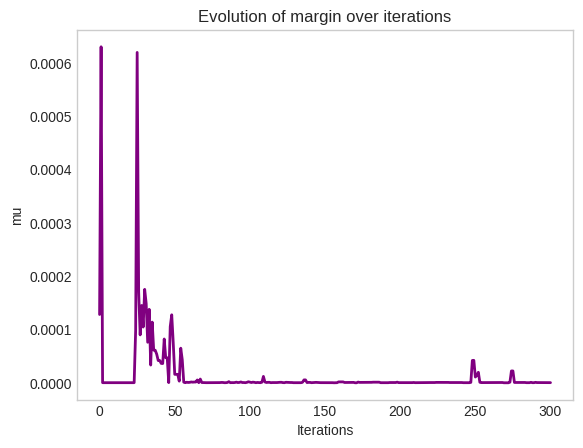

11:39:07 | INFO | ml_moo | Fit runtime: 3120.75 seconds


In [14]:
method = 'mola'
w_scalar = HateSpeechScalarization(train_dataloader=train_dataloader, device=device, model_name=model_name)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
#hypervolume_values = compute_hypervolume_progress(objs)
hypervolume_values = moopt.get_hypervolumes()
results[method] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

In [15]:
len(results['mola']['objectives'])

77

In [16]:
targets = ["General", "Women", "Homosexual", "Indigenous"]

In [17]:
results['mola']['objectives']

array([[0.58902257, 0.35190807, 0.26810233, 0.02298284],
       [0.5890469 , 0.35160752, 0.26818227, 0.02354376],
       [0.5888045 , 0.35216038, 0.26818836, 0.02298549],
       [0.58901312, 0.35194662, 0.26800634, 0.0229851 ],
       [0.59069923, 0.3562077 , 0.27089314, 0.02121854],
       [0.59056448, 0.3570482 , 0.27124051, 0.02122574],
       [0.58916298, 0.35196129, 0.26803348, 0.02297491],
       [0.58882074, 0.35196741, 0.26869414, 0.02297965],
       [0.58907991, 0.35295067, 0.26845336, 0.02295525],
       [0.58868042, 0.35241348, 0.26822036, 0.02297008],
       [0.58917438, 0.35166065, 0.26838933, 0.02296877],
       [0.58879002, 0.35180994, 0.26841789, 0.02298354],
       [0.59080982, 0.35660919, 0.27071101, 0.02127643],
       [0.59078029, 0.35647853, 0.27069844, 0.02132825],
       [0.59071217, 0.35712151, 0.27032385, 0.02140243],
       [0.59021732, 0.35534636, 0.27147199, 0.02143117],
       [0.59100372, 0.35568092, 0.27039655, 0.02146952],
       [0.5910705 , 0.35615481,

In [38]:
results['mola']['objectives']

array([[0.14536389, 0.07472787, 0.18076897, 0.71491565],
       [0.15551471, 0.02138629, 0.20020293, 0.94220672],
       [0.05435689, 0.11950789, 0.20168481, 0.71598708],
       [0.14141701, 0.0815697 , 0.15743136, 0.7158293 ],
       [0.84506488, 0.83781952, 0.859271  , 0.        ],
       [0.78882912, 0.98698958, 0.94372217, 0.00291725],
       [0.20395769, 0.0841728 , 0.16402958, 0.71170277],
       [0.06113421, 0.08526052, 0.32464987, 0.71362147],
       [0.16929188, 0.25976688, 0.26611081, 0.70373383],
       [0.00257571, 0.1644276 , 0.20946329, 0.70974535],
       [0.20871691, 0.03081703, 0.25054423, 0.7092148 ],
       [0.04831299, 0.05731207, 0.25748695, 0.71519896],
       [0.8912164 , 0.90907456, 0.81499088, 0.02345808],
       [0.87889117, 0.88588546, 0.81193549, 0.04445275],
       [0.85046247, 1.        , 0.72086392, 0.07451389],
       [0.64395574, 0.68495   , 1.        , 0.08616051],
       [0.97213246, 0.74432798, 0.73853971, 0.10169745],
       [1.        , 0.82843206,

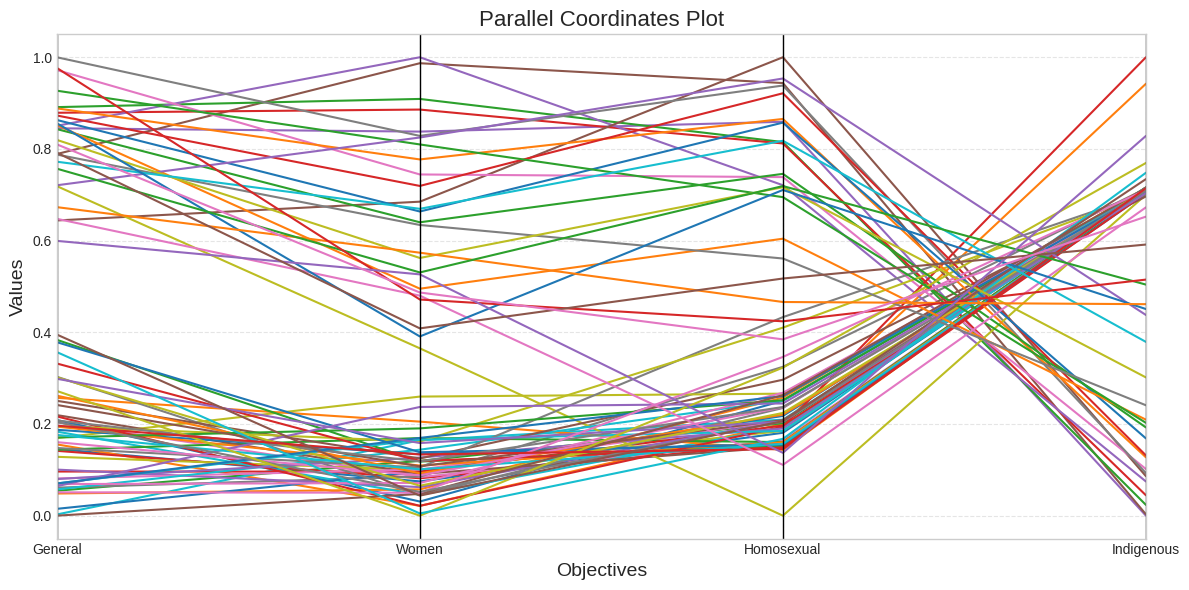

In [37]:
plot_parallel_coordinates(results['mola']['objectives'], labels=targets)

11:39:07 | DEBUG | ml_moo | Filtered parameters for Mola: {'node_time_limit': 2, 'target_size': 300, 'target_gap': 0, 'node_gap': 0.05, 'norm': False}
11:39:07 | DEBUG | ml_moo | Finding 1th individual minimum


device: cuda:0


Evaluating: 100%|██████████| 241/241 [00:01<00:00, 126.85it/s]
11:39:15 | DEBUG | ml_moo | Finding 2th individual minimum


device: cuda:0


Evaluating: 100%|██████████| 241/241 [00:01<00:00, 130.05it/s]
11:39:24 | DEBUG | ml_moo | Finding 3th individual minimum


...

12:28:14 | DEBUG | ml_moo | Calculated weights: [9.99956100e-01 4.46144629e-06 0.00000000e+00 3.94388367e-05]
12:28:14 | DEBUG | ml_moo | Importance: 9.658371456586114e-07
12:28:14 | DEBUG | ml_moo | Global lower bound (y*): [0.58865655 0.35164443 0.26641848 0.02166556]
12:28:14 | DEBUG | ml_moo | Iteration 300
12:28:14 | DEBUG | ml_moo | Solutions list: [array([0.58940897, 0.35212695, 0.26853998, 0.02276608]), array([0.58913896, 0.35234406, 0.26894893, 0.02277372]), array([0.58976173, 0.35298359, 0.26827472, 0.02277316]), array([0.58936916, 0.35246518, 0.26828421, 0.02277229]), array([0.58898711, 0.35339852, 0.26875409, 0.02279922]), array([0.58880379, 0.35249454, 0.26869725, 0.02281895]), array([0.58895407, 0.35225498, 0.26871573, 0.0228253 ]), array([0.58925498, 0.35277815, 0.26821333, 0.02282082]), array([0.58915267, 0.35251057, 0.26885048, 0.02277011]), array([0.58894264, 0.35366381, 0.26870735, 0.02277432]), array([0.58884677, 0.35267603, 0.26863991, 0.02280414]), array([0.588940

device: cuda:0


Evaluating: 100%|██████████| 241/241 [00:01<00:00, 127.58it/s]


new solution dominated [0.5891628  0.35253124 0.26858102 0.02277474]
load_solution=False and check results.termination_condition and
results.found_feasible_solution() before loading a solution.


12:28:24 | DEBUG | ml_moo | Calculated weights: [9.99956100e-01 4.46144629e-06 0.00000000e+00 3.94388367e-05]
12:28:24 | DEBUG | ml_moo | Importance: 9.658371456586114e-07
12:28:24 | DEBUG | ml_moo | Global lower bound (y*): [0.58865655 0.35164443 0.26641848 0.02166556]
12:28:24 | DEBUG | ml_moo | Iteration 301
12:28:24 | DEBUG | ml_moo | Solutions list: [array([0.58940897, 0.35212695, 0.26853998, 0.02276608]), array([0.58913896, 0.35234406, 0.26894893, 0.02277372]), array([0.58976173, 0.35298359, 0.26827472, 0.02277316]), array([0.58936916, 0.35246518, 0.26828421, 0.02277229]), array([0.58898711, 0.35339852, 0.26875409, 0.02279922]), array([0.58880379, 0.35249454, 0.26869725, 0.02281895]), array([0.58895407, 0.35225498, 0.26871573, 0.0228253 ]), array([0.58925498, 0.35277815, 0.26821333, 0.02282082]), array([0.58915267, 0.35251057, 0.26885048, 0.02277011]), array([0.58894264, 0.35366381, 0.26870735, 0.02277432]), array([0.58884677, 0.35267603, 0.26863991, 0.02280414]), array([0.588940

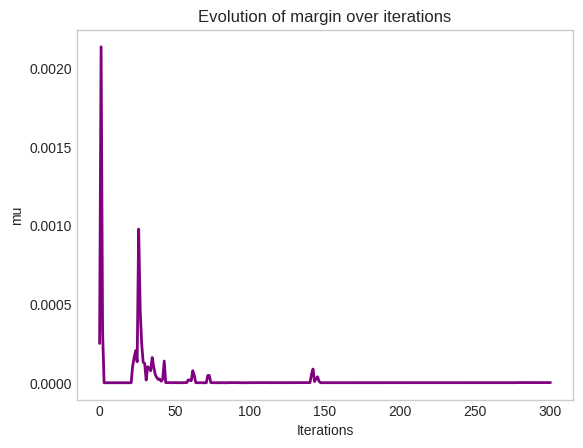

12:28:24 | INFO | ml_moo | Fit runtime: 2957.10 seconds


In [19]:
method = 'mola'
w_scalar = HateSpeechScalarization(train_dataloader=train_dataloader, device=device, model_name=model_name, gradient=True)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
#hypervolume_values = compute_hypervolume_progress(objs)
hypervolume_values = moopt.get_hypervolumes()
results[f"{method}_grad"] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

In [20]:
objs

array([[0.58940897, 0.35212695, 0.26853998, 0.02276608],
       [0.58913896, 0.35234406, 0.26894893, 0.02277372],
       [0.58976173, 0.35298359, 0.26827472, 0.02277316],
       [0.58936916, 0.35246518, 0.26828421, 0.02277229],
       [0.58898711, 0.35339852, 0.26875409, 0.02279922],
       [0.58880379, 0.35249454, 0.26869725, 0.02281895],
       [0.58895407, 0.35225498, 0.26871573, 0.0228253 ],
       [0.58925498, 0.35277815, 0.26821333, 0.02282082],
       [0.58915267, 0.35251057, 0.26885048, 0.02277011],
       [0.58894264, 0.35366381, 0.26870735, 0.02277432],
       [0.58884677, 0.35267603, 0.26863991, 0.02280414],
       [0.58894054, 0.35295869, 0.26889536, 0.02276959],
       [0.58909284, 0.35262667, 0.26906237, 0.02277515],
       [0.58917941, 0.35265235, 0.26876669, 0.02277028],
       [0.58914986, 0.35216888, 0.2689117 , 0.02277432],
       [0.58915805, 0.35238466, 0.26840509, 0.02277144],
       [0.58924274, 0.35207684, 0.26898213, 0.02282147],
       [0.58905057, 0.3528341 ,

In [39]:
results['mola_grad']['objectives']

array([[0.36003202, 0.17440089, 0.36645668, 0.6030844 ],
       [0.23083543, 0.25287294, 0.43709465, 0.60727166],
       [0.52882892, 0.48402232, 0.32063659, 0.60696636],
       [0.34098538, 0.29664903, 0.3222751 , 0.60648924],
       [0.1581745 , 0.63399201, 0.40343981, 0.62124294],
       [0.07045704, 0.30726175, 0.39362109, 0.63205546],
       [0.1423649 , 0.22067443, 0.39681322, 0.63553802],
       [0.28635067, 0.40976886, 0.31003144, 0.63308251],
       [0.23739234, 0.31305467, 0.42008996, 0.60529299],
       [0.13689491, 0.72987853, 0.39536577, 0.60759894],
       [0.0910216 , 0.37285892, 0.38371764, 0.62393928],
       [0.13588882, 0.47502089, 0.42784209, 0.6050096 ],
       [0.20876531, 0.35501701, 0.45668975, 0.60805656],
       [0.25018633, 0.36429904, 0.40561579, 0.60538877],
       [0.23604909, 0.18955714, 0.43066398, 0.60760158],
       [0.23996683, 0.26754763, 0.34315489, 0.60602478],
       [0.28049022, 0.15628844, 0.44283049, 0.63343677],
       [0.18854063, 0.42998873,

In [21]:
results['mola_grad']['objectives']

array([[0.58940897, 0.35212695, 0.26853998, 0.02276608],
       [0.58913896, 0.35234406, 0.26894893, 0.02277372],
       [0.58976173, 0.35298359, 0.26827472, 0.02277316],
       [0.58936916, 0.35246518, 0.26828421, 0.02277229],
       [0.58898711, 0.35339852, 0.26875409, 0.02279922],
       [0.58880379, 0.35249454, 0.26869725, 0.02281895],
       [0.58895407, 0.35225498, 0.26871573, 0.0228253 ],
       [0.58925498, 0.35277815, 0.26821333, 0.02282082],
       [0.58915267, 0.35251057, 0.26885048, 0.02277011],
       [0.58894264, 0.35366381, 0.26870735, 0.02277432],
       [0.58884677, 0.35267603, 0.26863991, 0.02280414],
       [0.58894054, 0.35295869, 0.26889536, 0.02276959],
       [0.58909284, 0.35262667, 0.26906237, 0.02277515],
       [0.58917941, 0.35265235, 0.26876669, 0.02277028],
       [0.58914986, 0.35216888, 0.2689117 , 0.02277432],
       [0.58915805, 0.35238466, 0.26840509, 0.02277144],
       [0.58924274, 0.35207684, 0.26898213, 0.02282147],
       [0.58905057, 0.3528341 ,

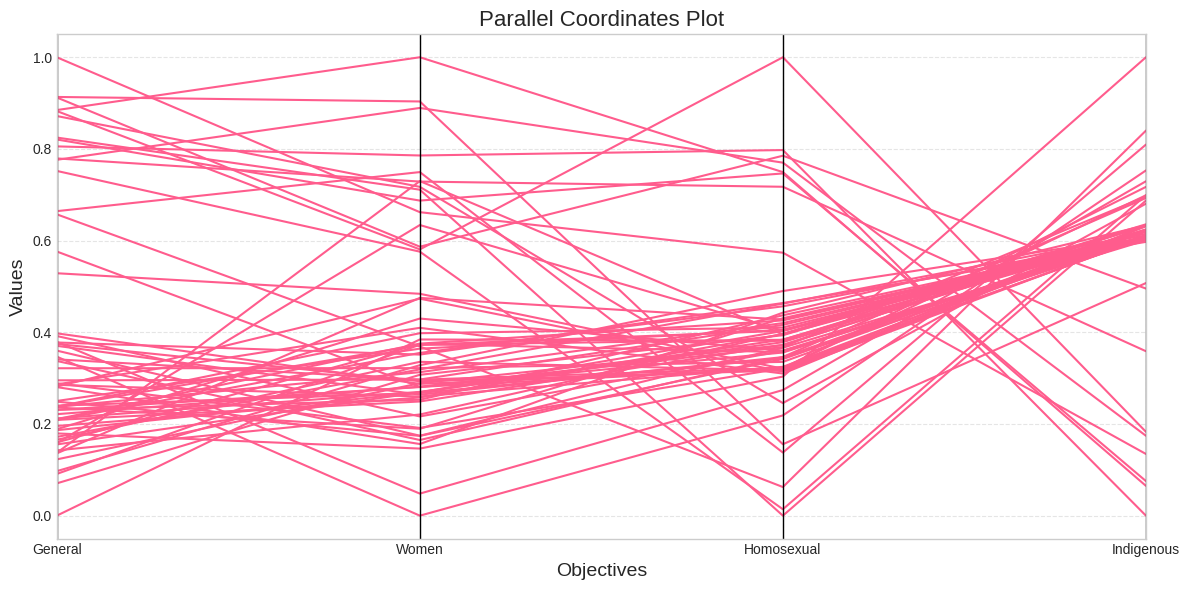

: 

In [ ]:
plot_parallel_coordinates(results['mola_grad']['objectives'], labels=targets, color="#FF5C8D")

## Random Weight

In [23]:
method = 'random_weight'
w_scalar = HateSpeechScalarization(train_dataloader=train_dataloader, device=device, model_name=model_name)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = compute_hypervolume_progress(objs)
results[method] = {
                "moopt": moopt,
                "objectives": objs,
                "models":  get_models(moopt),
                "hypervolume": hypervolume_values
            }

12:28:24 | WARNING | ml_moo | Ignored parameters for random_weights: {'nodeTimeLimit', 'targetGap', 'nodeGap'}
12:28:24 | DEBUG | ml_moo | Filtered parameters for random_weights: {'targetSize': 300, 'norm': False}
12:28:24 | DEBUG | ml_moo.moo.random_weights | Finding 1th individual minima


device: cuda:0


Evaluating: 100%|██████████| 241/241 [00:01<00:00, 132.79it/s]
12:28:33 | DEBUG | ml_moo.moo.random_weights | Finding 2th individual minima


device: cuda:0


Evaluating: 100%|██████████| 241/241 [00:01<00:00, 126.86it/s]
12:28:41 | DEBUG | ml_moo.moo.random_weights | Finding 3th individual minima


...

Evaluating: 100%|██████████| 241/241 [00:01<00:00, 144.41it/s]
13:07:45 | DEBUG | ml_moo.moo.random_weights | 298th solution


device: cuda:0


Evaluating: 100%|██████████| 241/241 [00:01<00:00, 134.05it/s]
13:07:52 | DEBUG | ml_moo.moo.random_weights | 299th solution


device: cuda:0


Evaluating: 100%|██████████| 241/241 [00:01<00:00, 140.02it/s]
13:08:00 | DEBUG | ml_moo.moo.random_weights | 300th solution


In [24]:
len(results['random_weight']['objectives'])

300

## Comparison between MOO methods

In [25]:
from ml_moo.tests.experiments.run import run_experiments
from ml_moo.analysis.moo_analyzer import Analyzer

In [49]:
results['random_weight']

{'moopt': <ml_moo.moo.random_weights.random_weights at 0x7e1d7a4496a0>,
 'objectives': array([[9.99824993e-01, 1.00000000e+00, 1.00000000e+00, 9.89588703e-01],
        [9.99605913e-01, 8.33168853e-01, 9.92143805e-01, 9.97843178e-01],
        [9.99161574e-01, 8.21993107e-01, 8.64794261e-01, 1.00000000e+00],
        ...,
        [7.60892272e-03, 2.40972216e-03, 1.71648208e-03, 3.15704740e-05],
        [4.67581859e-03, 1.50069430e-03, 2.13136735e-03, 2.73165038e-05],
        [7.36979271e-03, 9.30663146e-04, 1.13088674e-03, 2.29643623e-05]],
       shape=(300, 4)),
 'models': array([MultiTaskModel(
          (dropout): Dropout(p=0.3, inplace=False)
          (shared_fc): Linear(in_features=50, out_features=32, bias=True)
          (classifier_hate): Linear(in_features=32, out_features=2, bias=True)
          (classifier_women): Linear(in_features=32, out_features=2, bias=True)
          (classifier_homosexual): Linear(in_features=32, out_features=2, bias=True)
          (classifier_indigen

13:08:00 | WARNING | ml_moo | [Methods have different numbers of solutions: {64, 300, 77}


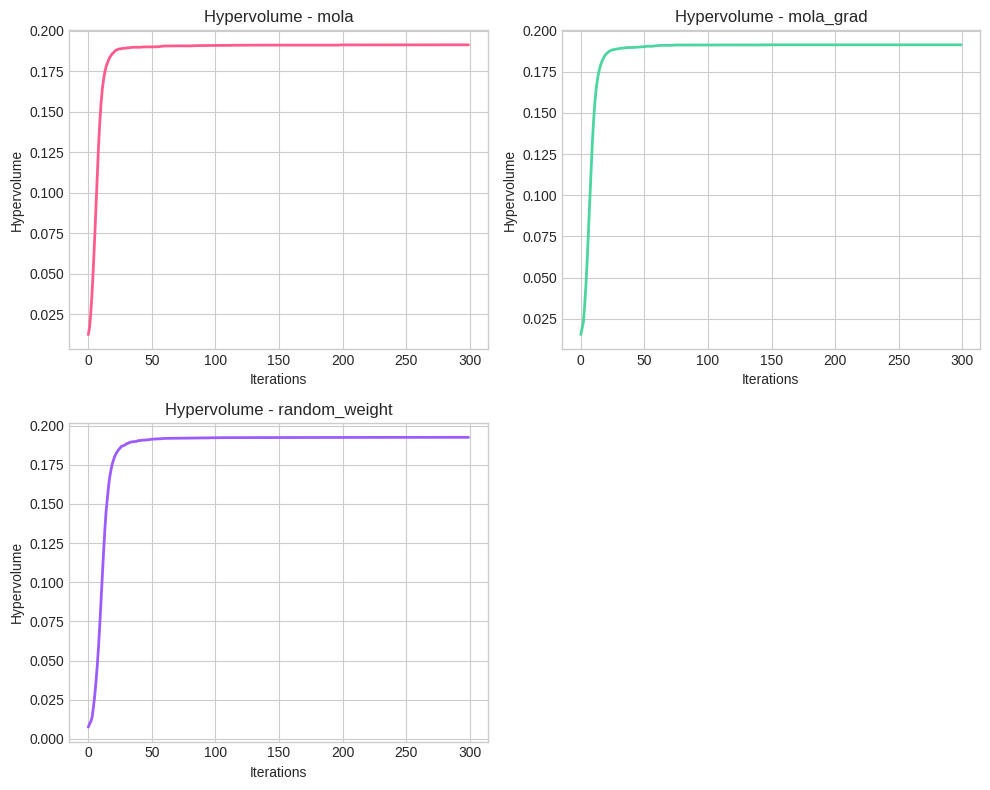

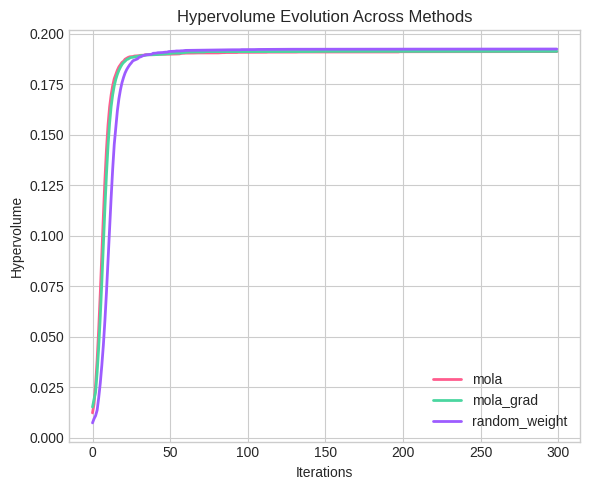

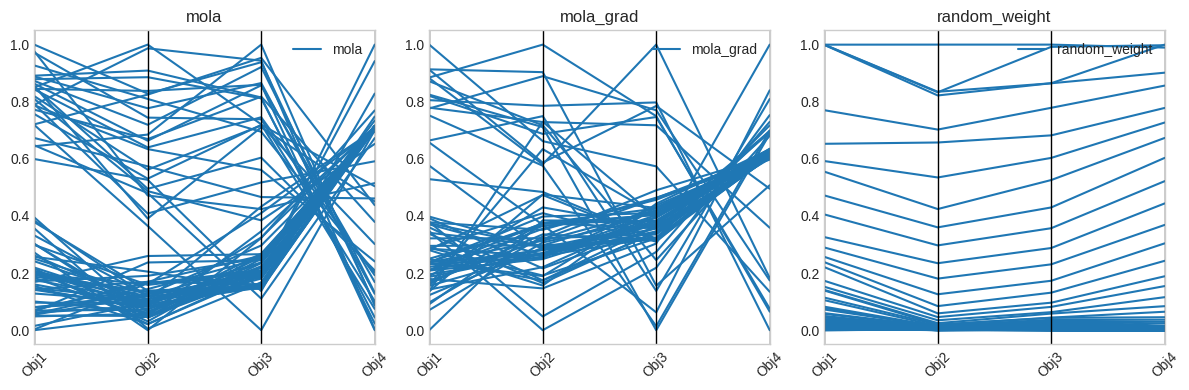

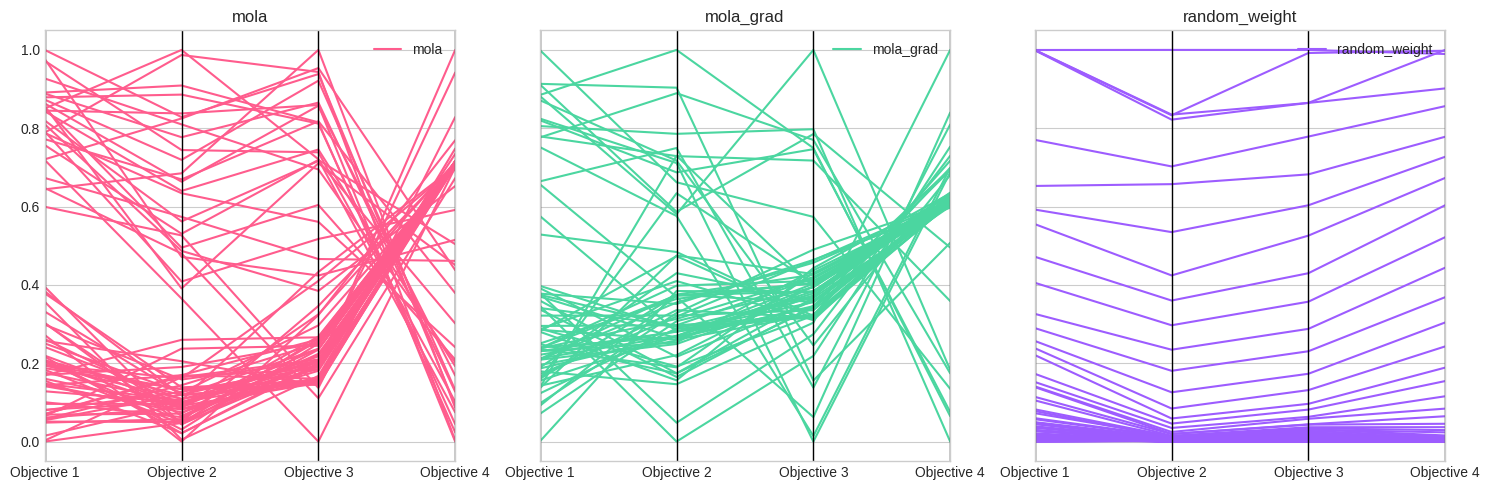

[Analyzer] Visualization complete.


In [26]:
pareto_dict = {
        method: res["objectives"]
        for method, res in results.items()
        if "objectives" in res
    }

hypervolumes_dict = {
        method: res["hypervolume"]
        for method, res in results.items()
        if "hypervolume" in res
    }

colors_pareto = ['#FF5C8D', '#FF5C8D', '#FF5C8D']
colors_hv = ['#FF5C8D', '#4BD6A0', '#9D5CFF']
title = ""
axis_label = targets

Analyzer.run_multiple(
                      pareto_dict = pareto_dict,
                      hypervolumes_values = hypervolumes_dict,
                      show_pareto = False, 
                      show_hypervolume = True,
                      show_parallel=True,
                      subplots = True,
                      subplots_hv = True,
                      colors_pareto=colors_hv,
                      colors_hv=colors_hv,
                      axis_label=axis_label
                      )

In [27]:
from ml_moo.analysis.visualization import (
    plot_parallel_coordinates_subplots, 
    plot_parallel_coordinates_all
)

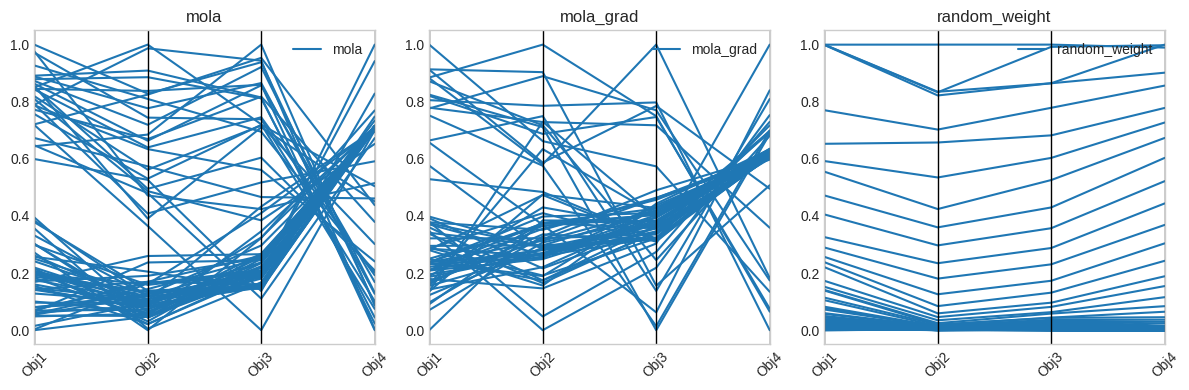

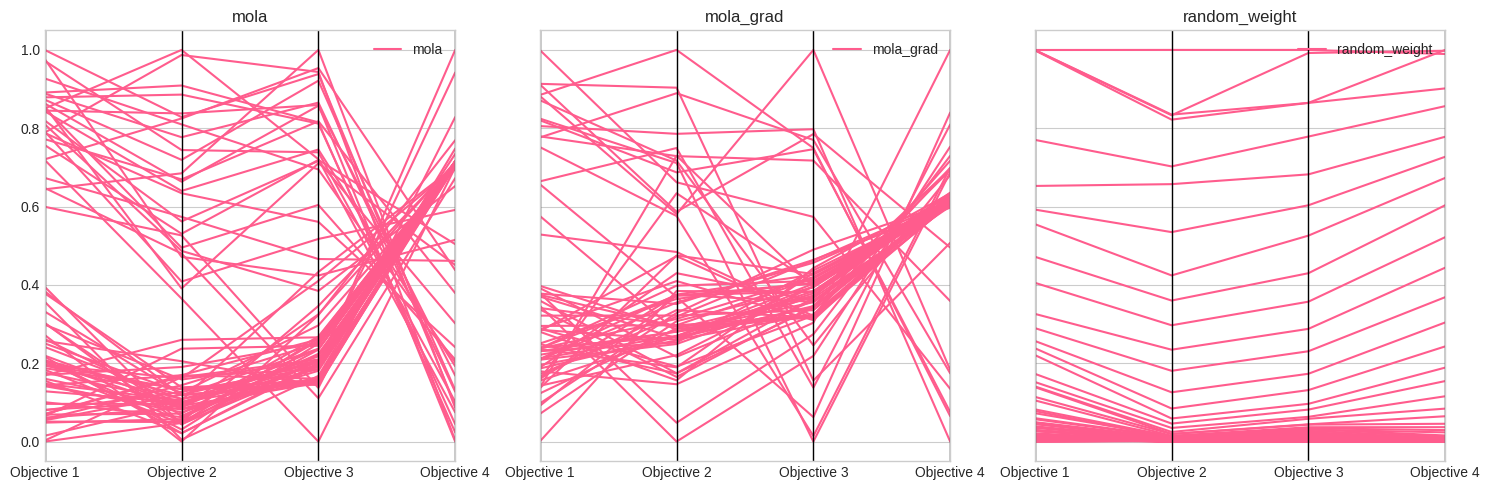

In [28]:
plot_parallel_coordinates_subplots(pareto_dict, )
plot_parallel_coordinates_all(pareto_dict, colors=colors_pareto)

In [29]:
from ml_moo.analysis.decision import get_best_median_solution, get_best_weighted_solution

In [30]:
objectives = results['mola']['objectives']
models = results['mola']['models']

In [31]:
objectives

array([[0.14536389, 0.07472787, 0.18076897, 0.71491565],
       [0.15551471, 0.02138629, 0.20020293, 0.94220672],
       [0.05435689, 0.11950789, 0.20168481, 0.71598708],
       [0.14141701, 0.0815697 , 0.15743136, 0.7158293 ],
       [0.84506488, 0.83781952, 0.859271  , 0.        ],
       [0.78882912, 0.98698958, 0.94372217, 0.00291725],
       [0.20395769, 0.0841728 , 0.16402958, 0.71170277],
       [0.06113421, 0.08526052, 0.32464987, 0.71362147],
       [0.16929188, 0.25976688, 0.26611081, 0.70373383],
       [0.00257571, 0.1644276 , 0.20946329, 0.70974535],
       [0.20871691, 0.03081703, 0.25054423, 0.7092148 ],
       [0.04831299, 0.05731207, 0.25748695, 0.71519896],
       [0.8912164 , 0.90907456, 0.81499088, 0.02345808],
       [0.87889117, 0.88588546, 0.81193549, 0.04445275],
       [0.85046247, 1.        , 0.72086392, 0.07451389],
       [0.64395574, 0.68495   , 1.        , 0.08616051],
       [0.97213246, 0.74432798, 0.73853971, 0.10169745],
       [1.        , 0.82843206,

In [32]:
best_solution, best_model, best_median, best_idx = get_best_median_solution(objectives, models)
print("ID Solução:", best_idx)
print("Melhor solução:", best_solution)
#print("Modelo correspondente:", best_model)
print("Mediana:", best_median)

ID Solução: 23
Melhor solução: [0.09629446 0.0960132  0.19651602 0.71426534]
Mediana: 0.1464052407402963


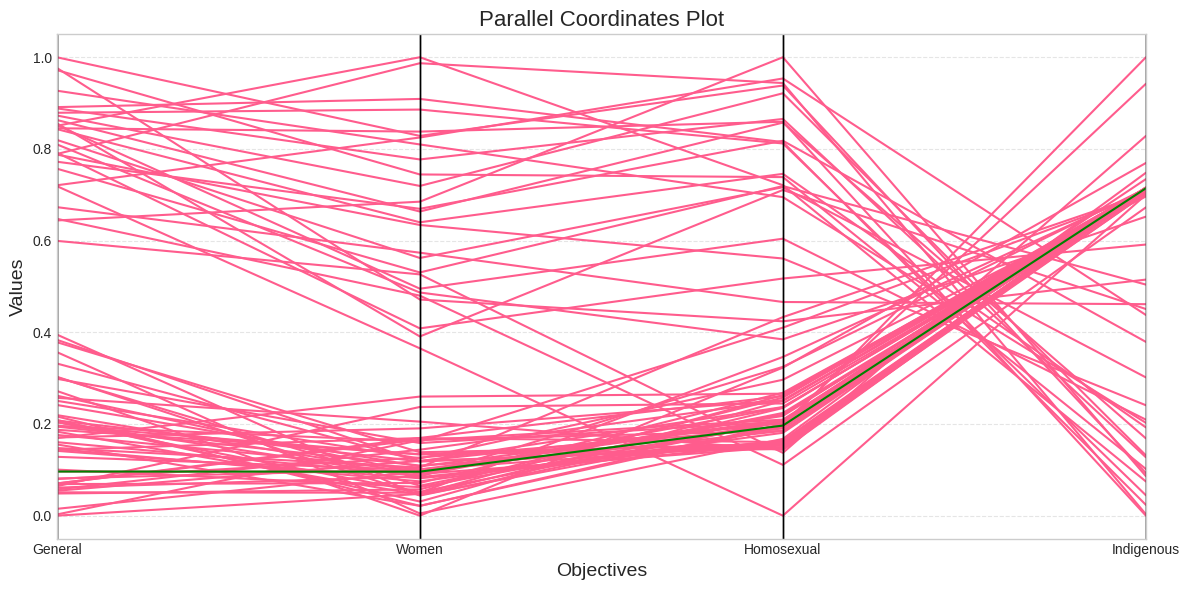

In [33]:
plot_parallel_coordinates(objectives, best_solution=best_solution, labels=targets, color="#FF5C8D", best_sol_label="Minor median solution")

In [34]:
weights = [0.1, 0.3, 0.2, 0.4]

In [35]:
best_solution, best_model, best_score, best_idx = get_best_weighted_solution(objectives, models, weights)

print("ID Solução:", best_idx)
print("Melhor solução:", best_solution)
#print("Modelo correspondente:", best_model)
print("Média ponderada:", best_score)

ID Solução: 19
Melhor solução: [0.18339076 0.04537722 0.19254765 0.70926072]
Média ponderada: 0.3541660577712573


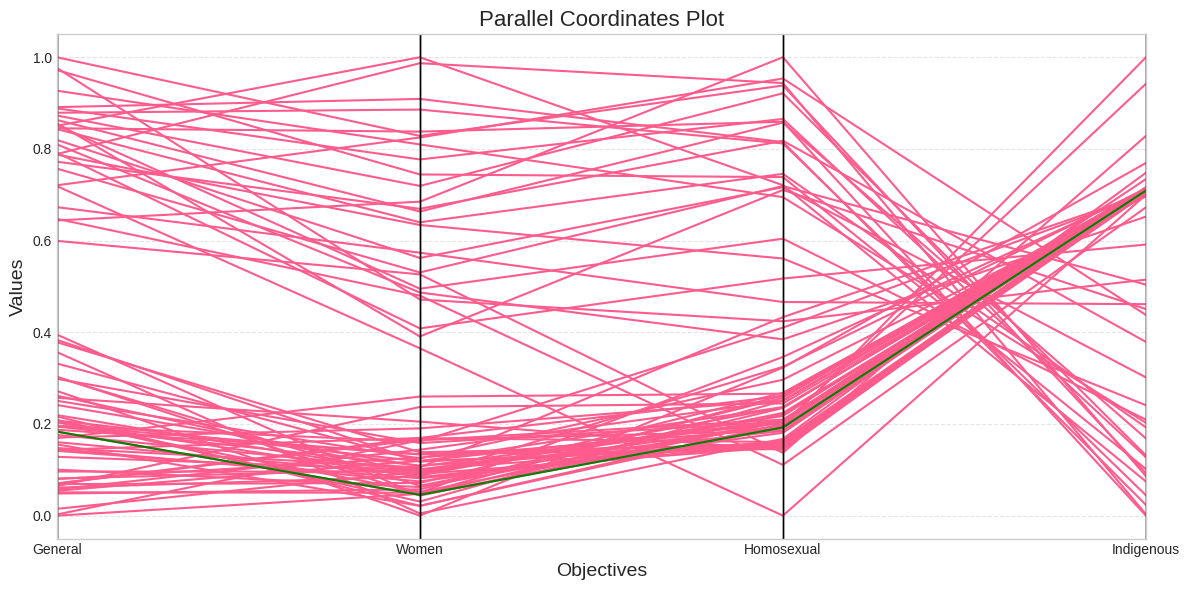

In [36]:
plot_parallel_coordinates(objectives, best_solution=best_solution, labels=targets, color="#FF5C8D", best_sol_label="Minor median solution")